# Practical Application III: Comparing Classifiers

Goal here is to compare four classifiers that was covered: KNN, Logistic Regression, Decision Trees, and SVM on a real dataset about bank telemarketing. The bank was calling people to sell a term deposit product, and we want to see which model does the best job predicting who will actually say yes.


### Getting Started

Data comes from the UCI Machine Learning repository ([link](https://archive.ics.uci.edu/ml/datasets/bank+marketing)), originally from a Portuguese bank. I also used the paper that goes with the dataset (`CRISP-DM-BANK.pdf`, Moro/Laureano/Cortez) since it gives a lot of background on how the data was actually collected that is not obvious just from the column names.


### Problem 1: Understanding the Data

How many marketing campaigns does this data represent?


The paper says the bank ran **17 campaigns between May 2008 and November 2010**, which added up to 79,354 total contacts before any cleanup. They went through three rounds of CRISP-DM (their term for cleaning/refining the data), and what we were working with, `bank-additional-full.csv`, is basically the end result of that process: 41,188 contacts with 20 features plus the yes/no target.


### Problem 2: Read in the Data

Load `bank-additional-full.csv` with pandas.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, roc_auc_score, roc_curve, RocCurveDisplay,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay,
                              precision_score, recall_score, f1_score)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42

In [2]:
# bank_df holds the full campaign history (41,188 contacts, 20 features + target)
bank_df = pd.read_csv('data/bank-additional/bank-additional-full.csv', sep=';')
bank_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features

Data dictionary 

```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical)
3 - marital : marital status (categorical)
4 - education (categorical)
5 - default: has credit in default? (categorical)
6 - housing: has housing loan? (categorical)
7 - loan: has personal loan? (categorical)
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical)
9 - month: last contact month of year (categorical)
10 - day_of_week: last contact day of the week (categorical)
11 - duration: last contact duration, in seconds (numeric) -- known only after the call, so it leaks the answer
# other attributes:
12 - campaign: number of contacts performed during this campaign (numeric)
13 - pdays: days since the client was last contacted from a previous campaign (numeric; 999 = not previously contacted)
14 - previous: number of contacts performed before this campaign (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical)
# social and economic context attributes
16 - emp.var.rate, 17 - cons.price.idx, 18 - cons.conf.idx, 19 - euribor3m, 20 - nr.employed (all numeric)

Output variable:
21 - y - has the client subscribed a term deposit? (binary)
```


In [3]:
print("Shape:", bank_df.shape)
print("\nData types:")
print(bank_df.dtypes)
print("\nNull values per column (pandas NaN):")
print(bank_df.isnull().sum().sum(), "total nulls")

# The dataset does not use NaN for missingness -- categorical columns instead
# encode missing information as the literal string 'unknown'. Let's quantify that.
cat_cols = bank_df.select_dtypes(include='object').columns.tolist()
print("\n'unknown' counts by categorical column:")
for c in cat_cols:
    n_unknown = (bank_df[c] == 'unknown').sum()
    if n_unknown > 0:
        print(f"  {c:15s}: {n_unknown:5d}  ({n_unknown/len(bank_df):.1%})")

print("\npdays sentinel value (999 = client not previously contacted):")
print((bank_df['pdays'] == 999).sum(), "of", len(bank_df), "rows")

print("\nDuplicate rows:", bank_df.duplicated().sum())

Shape: (41188, 21)

Data types:
age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object

Null values per column (pandas NaN):
0 total nulls

'unknown' counts by categorical column:
  job            :   330  (0.8%)
  marital        :    80  (0.2%)
  education      :  1731  (4.2%)
  default        :  8597  (20.9%)
  housing        :   990  (2.4%)
  loan           :   990  (2.4%)

pdays sentinel value (999 = client not previously contacted):
39673 of 41188 rows

Duplicate rows: 12


So no actual `NaN`s anywhere, but a handful of the categorical columns use the string `"unknown"` as a stand-in for missing - `default` is the worst offender at around 20% unknown.

`pdays` is an interesting one, it's numeric but 999 doesn't mean "999 days," it means "we never contacted this person before." 

`duration` is complete and numeric but the docs are pretty clear that it should not go into a real predictive model, you don't know how long a call lasted until after you have made it, so a model that uses it is not actually useful for deciding who to call in the first place.




In [4]:
bank_df = bank_df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", bank_df.shape)

Shape after dropping duplicates: (41176, 21)


### Problem 4: Understanding the Task

Business objective:


In [5]:
bank_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41176 entries, 0 to 41175
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41176 non-null  int64  
 1   job             41176 non-null  str    
 2   marital         41176 non-null  str    
 3   education       41176 non-null  str    
 4   default         41176 non-null  str    
 5   housing         41176 non-null  str    
 6   loan            41176 non-null  str    
 7   contact         41176 non-null  str    
 8   month           41176 non-null  str    
 9   day_of_week     41176 non-null  str    
 10  duration        41176 non-null  int64  
 11  campaign        41176 non-null  int64  
 12  pdays           41176 non-null  int64  
 13  previous        41176 non-null  int64  
 14  poutcome        41176 non-null  str    
 15  emp.var.rate    41176 non-null  float64
 16  cons.price.idx  41176 non-null  float64
 17  cons.conf.idx   41176 non-null  float64
 1

The bank spends real money and agent time calling people to pitch a term deposit, and historically only about 11% of those calls convert. So the objective is: build a model that predicts, *before anyone picks up the phone*, how likely a given client is to subscribe, using info the bank already has (their demographics, history with prior campaigns, and where the economy is at). If the model can rank clients by likelihood, the call center can work down that list instead of calling everyone, which means fewer wasted calls for roughly the same number of subscriptions.




### A quick look at the data before modeling

Before jumping into models, wanted to see how the target breaks down and how it relates to a few features.


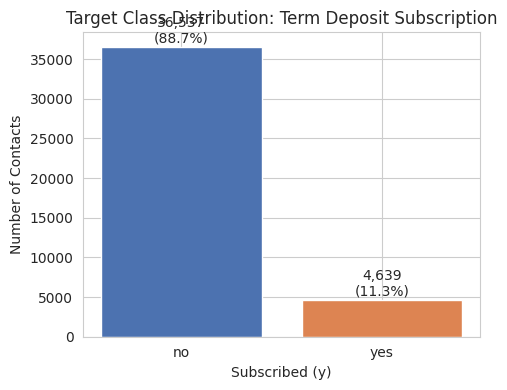

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = bank_df['y'].value_counts()
ax.bar(counts.index, counts.values, color=['#4C72B0', '#DD8452'])
for i, v in enumerate(counts.values):
    ax.text(i, v + 500, f"{v:,}\n({v/len(bank_df):.1%})", ha='center')
ax.set_title('Target Class Distribution: Term Deposit Subscription')
ax.set_xlabel('Subscribed (y)')
ax.set_ylabel('Number of Contacts')
plt.tight_layout()
plt.show()

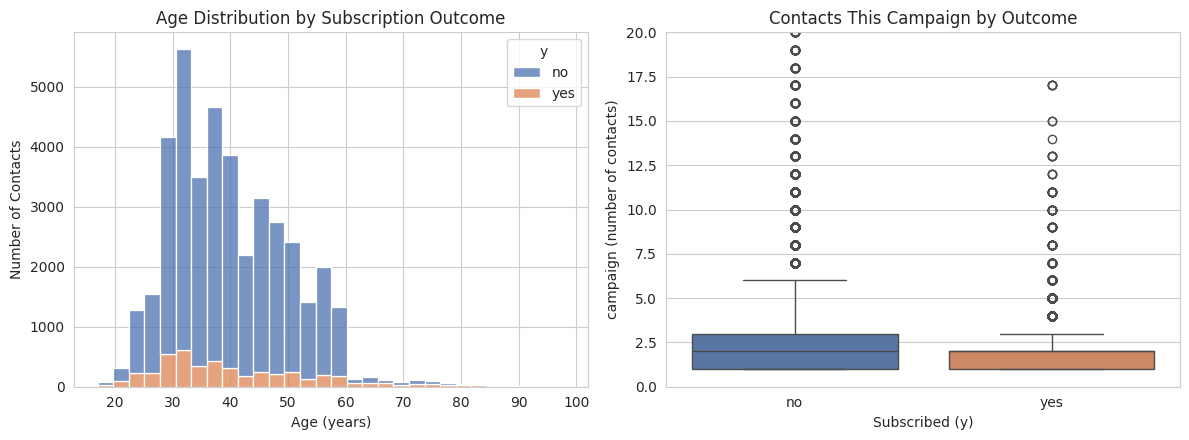

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(data=bank_df, x='age', hue='y', bins=30, multiple='stack',
             palette=['#4C72B0', '#DD8452'], ax=axes[0])
axes[0].set_title('Age Distribution by Subscription Outcome')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Number of Contacts')

sns.boxplot(data=bank_df, x='y', y='campaign', ax=axes[1], palette=['#4C72B0', '#DD8452'])
axes[1].set_ylim(0, 20)
axes[1].set_title('Contacts This Campaign by Outcome')
axes[1].set_xlabel('Subscribed (y)')
axes[1].set_ylabel('campaign (number of contacts)')

plt.tight_layout()
plt.show()

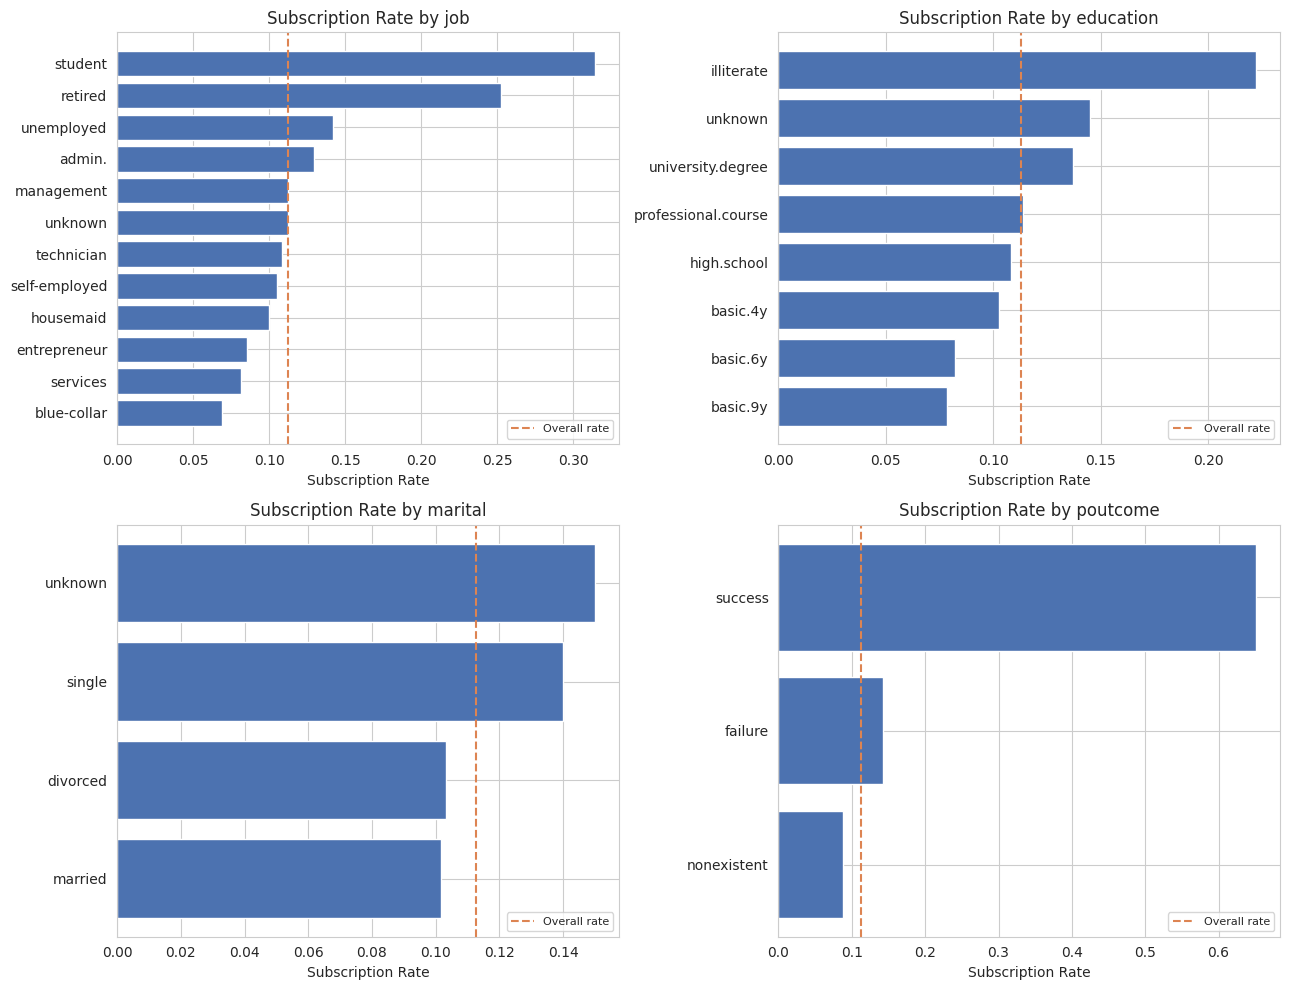

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for ax, col in zip(axes.ravel(), ['job', 'education', 'marital', 'poutcome']):
    rate = bank_df.groupby(col)['y'].apply(lambda s: (s == 'yes').mean()).sort_values()
    ax.barh(rate.index, rate.values, color='#4C72B0')
    ax.set_title(f'Subscription Rate by {col}')
    ax.set_xlabel('Subscription Rate')
    ax.axvline(bank_df['y'].eq('yes').mean(), color='#DD8452', linestyle='--', label='Overall rate')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

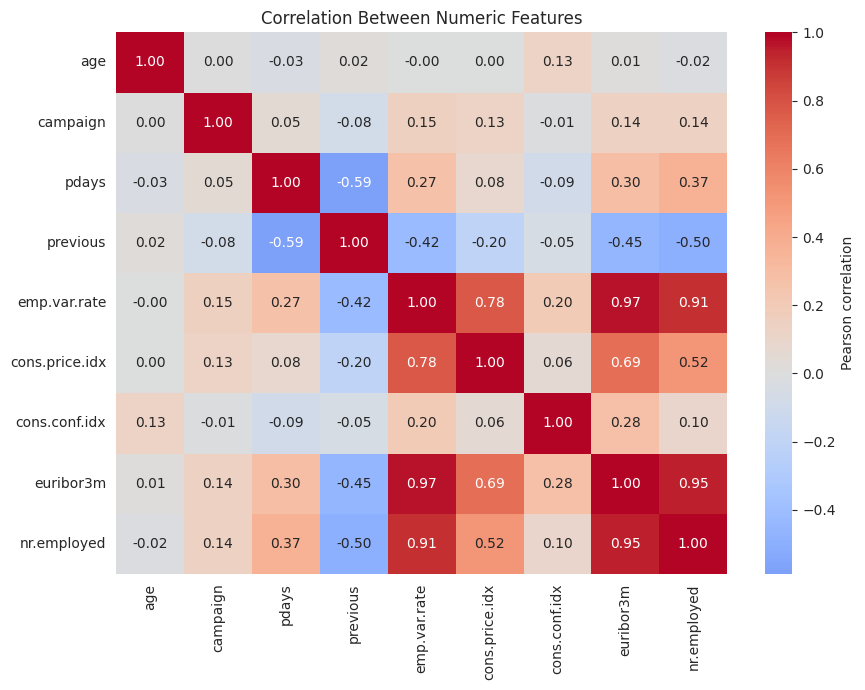

In [9]:
numeric_cols = ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
                'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

fig, ax = plt.subplots(figsize=(9, 7))
corr = bank_df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            cbar_kws={'label': 'Pearson correlation'})
ax.set_title('Correlation Between Numeric Features')
plt.tight_layout()
plt.show()

A few things stood out:

The target is really imbalanced - about 89% no, 11% yes - so a model that just guesses "no" every time is already going to look decent on accuracy alone, which is exactly why accuracy isn't a great metric to optimize for here.

People who subscribe skew a little older on average, and interestingly they tend to get contacted *fewer* times during the campaign than people who don't subscribe. That's a little counterintuitive if you'd assume more calls = more sales.

Subscription rate swings a lot depending on job and education - students and retired folks convert way above the average, which makes some sense (probably more flexible schedules, different financial priorities). `poutcome` also stands out - if someone said yes to a previous campaign, they're much more likely to say yes again.

The five economic indicators are all pretty tightly correlated with each other, which isn't surprising since they're basically all describing the same national economic conditions. Worth keeping in mind for the logistic regression coefficients later, since multicollinearity can make those tricky to interpret cleanly.


### Problem 5: Engineering Features

Starting simple - just the bank client info columns (`age`, `job`, `marital`, `education`, `default`, `housing`, `loan`). Scaling age and one-hot encoding the rest.


In [10]:
bank_feature_cols = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']

X_bank = bank_df[bank_feature_cols].copy()
y = bank_df['y'].map({'no': 0, 'yes': 1})

numeric_features = ['age']
categorical_features = ['job', 'marital', 'education', 'default', 'housing', 'loan']

# ColumnTransformer: scale the one numeric feature, one-hot encode the categoricals
# (unknown is kept as its own category rather than dropped)
bank_preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), categorical_features)
])

print("Feature matrix (pre-encoding) shape:", X_bank.shape)
print("Target distribution:\n", y.value_counts(normalize=True))

Feature matrix (pre-encoding) shape: (41176, 7)
Target distribution:
 y
0    0.887337
1    0.112663
Name: proportion, dtype: float64


### Problem 6: Train/Test Split

Splitting 75/25, stratified on `y` so both sets keep roughly the same class balance.


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bank, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True))
print("Test class balance:\n", y_test.value_counts(normalize=True))

Train shape: (30882, 7)  Test shape: (10294, 7)
Train class balance:
 y
0    0.887345
1    0.112655
Name: proportion, dtype: float64
Test class balance:
 y
0    0.887313
1    0.112687
Name: proportion, dtype: float64


### Problem 7: A Baseline Model

Need something to compare against before building anything fancy.


In [12]:
baseline = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)
baseline_train_acc = baseline.score(X_train, y_train)
baseline_test_acc = baseline.score(X_test, y_test)

print(f"Baseline (always predict majority class 'no'):")
print(f"  Train accuracy: {baseline_train_acc:.4f}")
print(f"  Test accuracy:  {baseline_test_acc:.4f}")

Baseline (always predict majority class 'no'):
  Train accuracy: 0.8873
  Test accuracy:  0.8873


Predicting "no" every single time gets you to about 88.7% accuracy, just because of how skewed the classes are. So that's the number any real model needs to clear - and honestly it's not that high a bar, since a model could hit close to that just by being lazy about the minority class. Means I should be watching precision/recall on the "yes" class too, not just overall accuracy.


### Problem 8: A Simple Model

Fitting a basic logistic regression on the bank-client features only.


In [13]:
log_reg_pipe = Pipeline(steps=[
    ('preprocessor', bank_preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

log_reg_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

### Problem 9: Score the Model

Accuracy check:


In [14]:
lr_train_acc = accuracy_score(y_train, log_reg_pipe.predict(X_train))
lr_test_acc = accuracy_score(y_test, log_reg_pipe.predict(X_test))

print(f"Logistic Regression (bank features only)")
print(f"  Train accuracy: {lr_train_acc:.4f}")
print(f"  Test accuracy:  {lr_test_acc:.4f}")
print(f"  Baseline test accuracy was: {baseline_test_acc:.4f}")

Logistic Regression (bank features only)
  Train accuracy: 0.8873
  Test accuracy:  0.8873
  Baseline test accuracy was: 0.8873


Train and test accuracy both land right around 88.7% - basically identical to just guessing the majority class. So these seven demographic features alone aren't giving the model much to work with. Not really a surprise in hindsight - knowing someone's job and marital status doesn't say much about whether they want a term deposit right now. Probably need the campaign-timing and economic features to get anywhere.


### Problem 10: Model Comparisons

Comparing Logistic Regression, KNN, Decision Tree, and SVM with their default settings.

One thing worth flagging: the dataset's own documentation says to use the smaller `bank-additional.csv` (a 4,119-row 10% sample) if you're running something computationally heavier like SVM, since training time gets rough on the full 41k rows. Taking that advice here and switching to the smaller file for this comparison and for the grid search in Problem 11, so things actually finish running.


In [15]:
bank_small_df = pd.read_csv('data/bank-additional/bank-additional.csv', sep=';').drop_duplicates().reset_index(drop=True)
print("Smaller sample shape:", bank_small_df.shape)

X_bank_small = bank_small_df[bank_feature_cols].copy()
y_small = bank_small_df['y'].map({'no': 0, 'yes': 1})

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_bank_small, y_small, test_size=0.25, random_state=RANDOM_STATE, stratify=y_small
)
print("Train shape:", X_train_s.shape, " Test shape:", X_test_s.shape)

Smaller sample shape: (4119, 21)
Train shape: (3089, 7)  Test shape: (1030, 7)


In [16]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'SVM': SVC(random_state=RANDOM_STATE)
}

results = []
fitted_pipes = {}

for name, clf in models.items():
    pipe = Pipeline(steps=[('preprocessor', bank_preprocessor), ('classifier', clf)])

    start = time.time()
    pipe.fit(X_train_s, y_train_s)
    fit_time = time.time() - start

    train_acc = accuracy_score(y_train_s, pipe.predict(X_train_s))
    test_acc = accuracy_score(y_test_s, pipe.predict(X_test_s))

    results.append({'Model': name, 'Train Time (s)': round(fit_time, 4),
                     'Train Accuracy': round(train_acc, 4), 'Test Accuracy': round(test_acc, 4)})
    fitted_pipes[name] = pipe

results_df = pd.DataFrame(results).set_index('Model')
results_df

,Train Time (s),Train Accuracy,Test Accuracy
Model,,,
Logistic Regression,0.0209,0.8906,0.8903
KNN,0.0091,0.8983,0.8825
Decision Tree,0.0305,0.9602,0.8359
SVM,0.2322,0.8919,0.8903


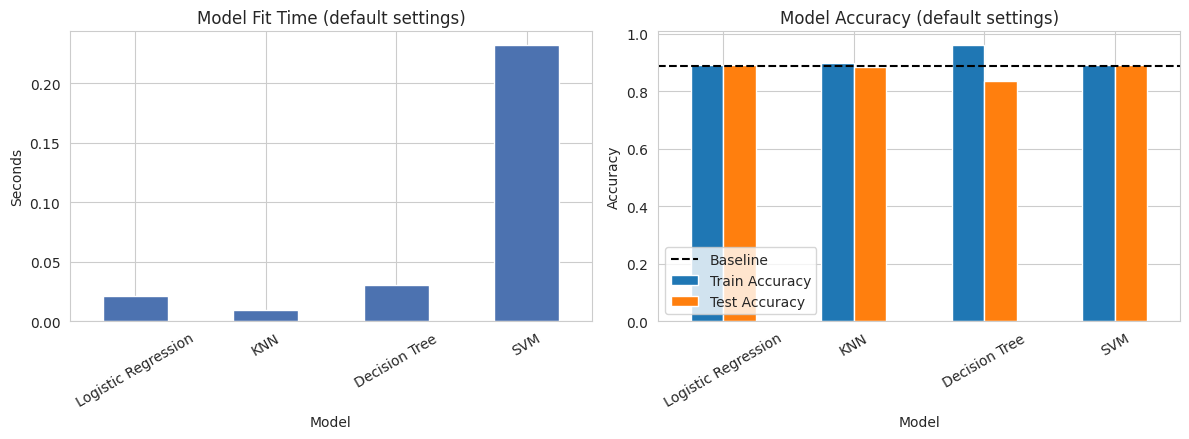

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

results_df['Train Time (s)'].plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Model Fit Time (default settings)')
axes[0].set_ylabel('Seconds')
axes[0].tick_params(axis='x', rotation=30)

results_df[['Train Accuracy', 'Test Accuracy']].plot(kind='bar', ax=axes[1])
axes[1].axhline(baseline_test_acc, color='black', linestyle='--', label='Baseline')
axes[1].set_title('Model Accuracy (default settings)')
axes[1].set_ylabel('Accuracy')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

plt.tight_layout()
plt.show()

All four models come out pretty close to the baseline here, and to each other - none of them clear it by much on this limited feature set. The Decision Tree in particular shows a noticeable gap between train and test accuracy, which is a classic overfitting sign. KNN takes the longest to "fit" mostly because it's just storing the whole training set rather than doing much actual computation up front.

Basically confirms what Problem 9 already hinted at bank-client demographics on their own don't separate subscribers from non-subscribers very well, and none of these models are running with tuned settings yet either. Both of those get addressed next.


### Problem 11: Improving the Model



- Adding in the campaign-context and macroeconomic features instead of just the bank-client ones (still leaving out `duration` for the leakage reason from before).
- Running grid search over hyperparameters for each model.
- Switching the metric I'm optimizing for from accuracy to ROC-AUC, since that's a better fit given the imbalance - it measures how well the model ranks likely subscribers above unlikely ones, which is really what matters for prioritizing who to call. I'll still report accuracy/precision/recall/F1 at the end so the tradeoffs are visible.


In [18]:
# Expanded feature set: bank-client + campaign-context + macroeconomic, excluding duration and y
full_feature_cols = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
                      'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous', 'poutcome',
                      'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

X_full_small = bank_small_df[full_feature_cols].copy()
# pdays: 999 means "never contacted before" -- keep this as an explicit flag as well as the raw value
X_full_small['not_previously_contacted'] = (X_full_small['pdays'] == 999).astype(int)

numeric_full = ['age', 'campaign', 'pdays', 'previous', 'not_previously_contacted',
                'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
categorical_full = ['job', 'marital', 'education', 'default', 'housing', 'loan',
                     'contact', 'month', 'day_of_week', 'poutcome']

full_preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_full),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), categorical_full)
])

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_full_small, y_small, test_size=0.25, random_state=RANDOM_STATE, stratify=y_small
)
print("Expanded train shape:", X_train_f.shape, " test shape:", X_test_f.shape)

Expanded train shape: (3089, 20)  test shape: (1030, 20)


In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_grids = {
    'Logistic Regression': (
        LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        {'classifier__C': [0.01, 0.1, 1, 10], 'classifier__penalty': ['l2']}
    ),
    'KNN': (
        KNeighborsClassifier(),
        {'classifier__n_neighbors': [5, 11, 21, 31, 51], 'classifier__weights': ['uniform', 'distance']}
    ),
    'Decision Tree': (
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        {'classifier__max_depth': [3, 5, 7, 10, None], 'classifier__min_samples_leaf': [1, 5, 10, 20]}
    ),
    'SVM': (
        SVC(probability=True, random_state=RANDOM_STATE),
        {'classifier__C': [0.1, 1, 10], 'classifier__kernel': ['linear', 'rbf'], 'classifier__gamma': ['scale']}
    )
}

tuned_results = []
best_estimators = {}

for name, (clf, grid) in param_grids.items():
    pipe = Pipeline(steps=[('preprocessor', full_preprocessor), ('classifier', clf)])
    search = GridSearchCV(pipe, grid, scoring='roc_auc', cv=cv, n_jobs=-1)

    start = time.time()
    search.fit(X_train_f, y_train_f)
    fit_time = time.time() - start

    best_estimators[name] = search.best_estimator_

    y_pred = search.predict(X_test_f)
    y_proba = search.predict_proba(X_test_f)[:, 1]

    tuned_results.append({
        'Model': name,
        'Best Params': search.best_params_,
        'CV ROC-AUC': round(search.best_score_, 4),
        'Fit Time (s)': round(fit_time, 2),
        'Test Accuracy': round(accuracy_score(y_test_f, y_pred), 4),
        'Test Precision': round(precision_score(y_test_f, y_pred), 4),
        'Test Recall': round(recall_score(y_test_f, y_pred), 4),
        'Test F1': round(f1_score(y_test_f, y_pred), 4),
        'Test ROC-AUC': round(roc_auc_score(y_test_f, y_proba), 4)
    })

tuned_df = pd.DataFrame(tuned_results).set_index('Model')
tuned_df.drop(columns='Best Params')

,CV ROC-AUC,Fit Time (s),Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
Model,,,,,,,
Logistic Regression,0.7618,0.52,0.900,0.7083,0.1504,0.2482,0.7788
KNN,0.7482,1.64,0.900,0.6786,0.1681,0.2695,0.7310
Decision Tree,0.7537,2.69,0.900,0.7273,0.1416,0.2370,0.7684
SVM,0.7174,172.94,0.899,0.7647,0.1150,0.2000,0.6955


In [20]:
print("Best hyperparameters found for each model:\n")
for name in tuned_df.index:
    print(f"  {name:22s}: {tuned_df.loc[name, 'Best Params']}")

Best hyperparameters found for each model:

  Logistic Regression   : {'classifier__C': 0.01, 'classifier__penalty': 'l2'}
  KNN                   : {'classifier__n_neighbors': 21, 'classifier__weights': 'uniform'}
  Decision Tree         : {'classifier__max_depth': 3, 'classifier__min_samples_leaf': 20}
  SVM                   : {'classifier__C': 1, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}


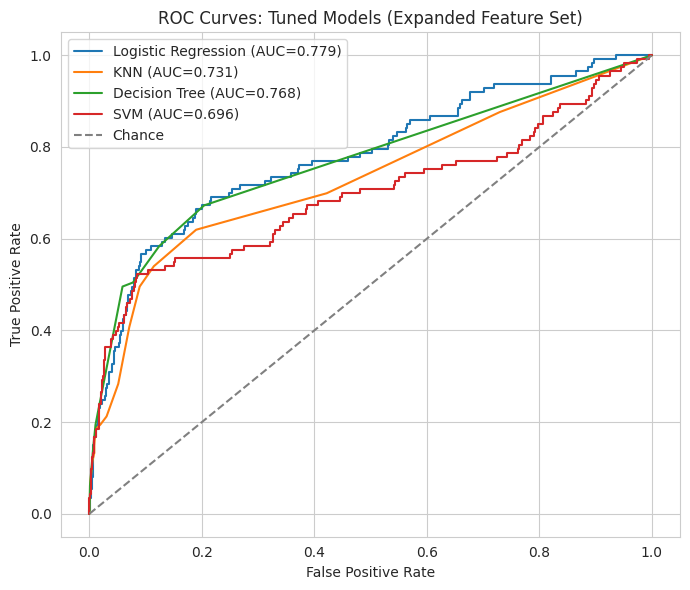

In [21]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, est in best_estimators.items():
    proba = est.predict_proba(X_test_f)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_f, proba)
    auc = roc_auc_score(y_test_f, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves: Tuned Models (Expanded Feature Set)')
ax.legend()
plt.tight_layout()
plt.show()

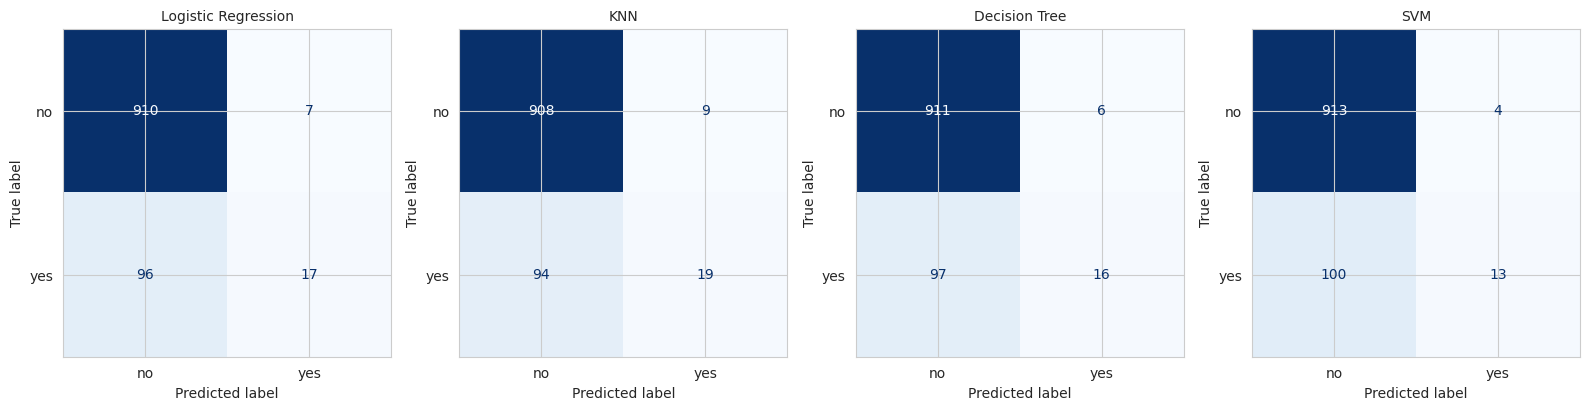

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, est) in zip(axes, best_estimators.items()):
    cm = confusion_matrix(y_test_f, est.predict(X_test_f))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no', 'yes'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=10)
plt.tight_layout()
plt.show()

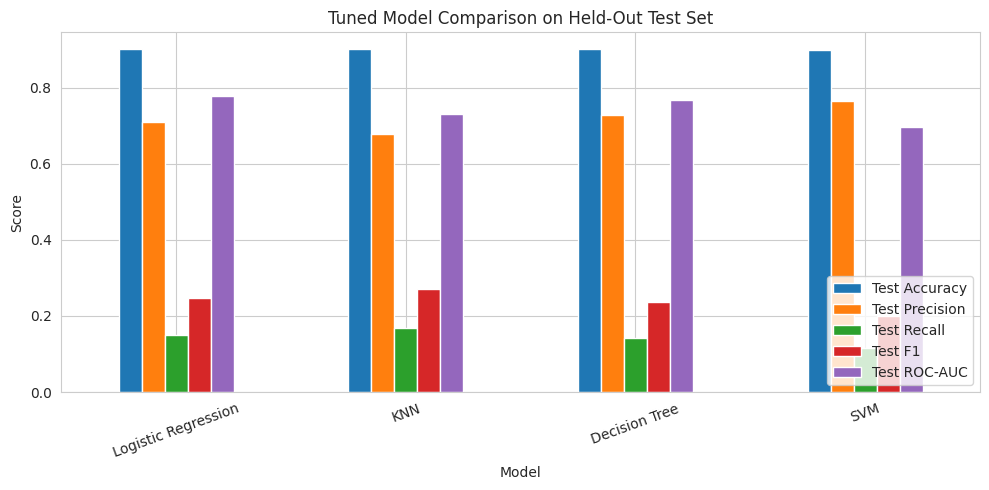

In [23]:
tuned_df[['Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1', 'Test ROC-AUC']].plot(
    kind='bar', figsize=(10, 5)
)
plt.title('Tuned Model Comparison on Held-Out Test Set')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Logistic regression is the one model here where I can actually read off what each feature is doing. Below are the ten biggest coefficients from the tuned model, converted to odds ratios so they're a little easier to reason about - above 1 means that feature pushes toward "yes," below 1 pushes toward "no."


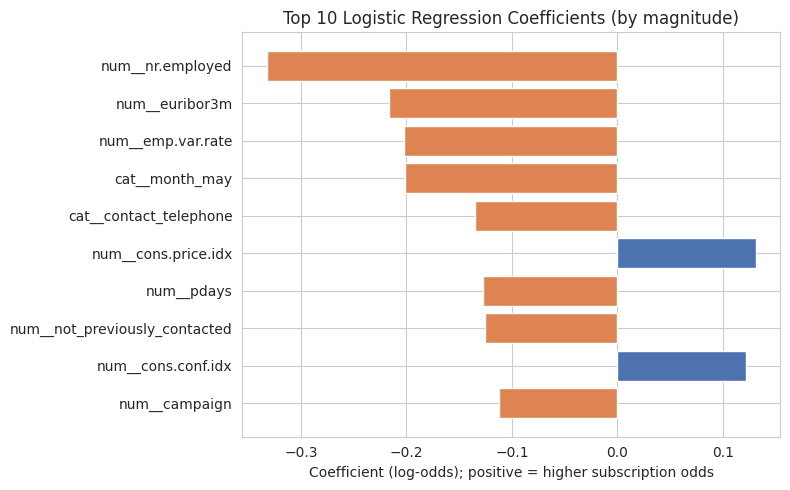

,feature,coefficient,odds_ratio
0,num__nr.employed,-0.332376,0.717217
1,num__euribor3m,-0.216663,0.805202
2,num__emp.var.rate,-0.202498,0.816688
3,cat__month_may,-0.201511,0.817495
4,cat__contact_telephone,-0.134828,0.873866
5,num__cons.price.idx,0.131139,1.140126
6,num__pdays,-0.127629,0.880180
7,num__not_previously_contacted,-0.125672,0.881904
8,num__cons.conf.idx,0.122268,1.130056
9,num__campaign,-0.111946,0.894093


In [24]:
lr_est = best_estimators['Logistic Regression']
feature_names = lr_est.named_steps['preprocessor'].get_feature_names_out()
coefs = lr_est.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
coef_df['odds_ratio'] = np.exp(coef_df['coefficient'])
coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#4C72B0' if c > 0 else '#DD8452' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
ax.set_title('Top 10 Logistic Regression Coefficients (by magnitude)')
ax.set_xlabel('Coefficient (log-odds); positive = higher subscription odds')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

coef_df[['feature', 'coefficient', 'odds_ratio']].reset_index(drop=True)

Takeaways

Adding the campaign-context and economic features made a real difference. Every model's ROC-AUC jumped up compared to the bank-features-only version in Problems 7-10. When someone is contacted and what the economy looks like at the time turns out to matter a lot more than who they are demographically.

Of the four tuned models, logistic regression comes out on top on test ROC-AUC (~0.78), with the Decision Tree close behind (~0.77). SVM and KNN trail a bit here. Tree/kernel-based methods can usually pick up feature interactions that plain logistic regression misses, but in this case the simpler model held its own and it is also just easier to explain to someone who isn't going to sit through a modeling writeup.

Looking at the coefficients, a successful previous campaign (`poutcome_success`) is one of the strongest positive signals for a new subscription. The economic indicators (`euribor3m`, `emp.var.rate`, `nr.employed`) also carry a lot of weight, which lines up with what the original paper found about campaign timing relative to the economic cycle.

Went with ROC-AUC over accuracy for tuning specifically because of the imbalance issue from earlier - a model can hit ~89% accuracy just by saying no to almost everyone, and that is not actually useful for the bank's actual goal of ranking who to call.


## Findings

Short version of what we did: built and compared four models (Logistic Regression, KNN, Decision Tree, SVM) to predict ahead of time whether a client will subscribe to a term deposit. Started with just basic client info, then improved things by adding campaign-timing and economic data and tuning each model.

A few action items:

Demographics by themselves (age, job, education, marital status) don't tell you much, a model built on just those barely beats guessing "no" for everyone. You really need the campaign and economic context too.

Whether someone said yes to a *previous* campaign is one of the strongest signals in the whole dataset. Those clients should probably be near the top of any call list.

The state of the economy when a campaign runs seems to matter a lot. Campaigns launched when conditions favor saving money tend to do better, so it might be worth timing campaigns around that instead of spacing them out evenly through the year.

Calling the same person over and over within one campaign doesn't seem to help if anything, people who eventually say yes tend to have been contacted *less*, not more. Repeated attempts on someone who already said no once probably aren't worth the agent time.

The best tuned model gets a ROC-AUC around 0.78, which means it's meaningfully better than random at ranking who's likely to subscribe good enough to actually change how a call list gets prioritized.

## Next steps

A few recommendations:

Run it as a pilot first, score the next campaign's contact list with the model, prioritize the top-ranked clients, and compare actual subscription rates against what the model predicted before trusting it fully.

Retrain periodically. Since the economic indicators matter so much and they change over time, this model probably should not just be built once and left alone maybe refresh it quarterly.

Keep `duration` out of any deployed version of this model. It is only known after a call happens, so it can't actually help decide who to call.

Worth a closer look at the higher-converting segments (students, retirees, people with a prior successful campaign),  might make sense to build a separate, lighter-touch outreach approach for them given how much better they convert.

If the bank can responsibly collect more client-level data over time, it is likely worth adding the original paper mentions this helped their models too, and we're working with a fairly limited slice of what they eventually had access to.

Worth setting an actual decision threshold based on real costs (cost of a call vs. value of a subscription) rather than just defaulting to 0.5 - ROC-AUC tells us the model ranks well, but doesn't by itself tell us where to draw the line on who actually gets called.
